# Predicting Emerging Community Bridges in Reddit Using Social Network Analysis and Link Prediction

## Introduction
Social networks are highly dynamic environments where communities constantly evolve, interact, and form new structural bridges. On platforms like Reddit, individual communities (subreddits) frequently reference one another via hyperlinks, creating a massive, complex network of information flow, cultural exchange, and platform polarization.

## Problem Definition
Understanding how and why digital communities interact is crucial for modeling information diffusion, measuring platform polarization, and predicting the formation of echo chambers. The core problem this project addresses is **Community Bridge Prediction**: Given a static snapshot of subreddit-to-subreddit interactions, can we predict which communities are most likely to form *new* hyperlinks with each other in the future, relying purely on the underlying topological structure of the network?

## Objectives
1. **Network Construction:** Project a massive, temporal, directed hyperlink dataset into a clean, undirected, and unweighted graph suitable for foundational topological analysis.
2. **Exploratory SNA:** Analyze macro and micro-level structural properties of the Reddit network (e.g., degree distribution, density, connected components).
3. **Community Detection:** Identify modular community structures on the training graph using Louvain community detection.
4. **Link Prediction:** Formulate bridge prediction as a Link Prediction problem, evaluating baseline topological heuristics: *Common Neighbors*, *Jaccard Coefficient*, *Adamic-Adar Index*, and *Preferential Attachment*.
5. **Evaluation & Bridge Analysis:** Rigorously evaluate predictions using ranking-based and threshold-based metrics, and analyze whether top-predicted candidate links bridge distinct Reddit communities.

## SDG Mapping
This project aligns with the United Nations Sustainable Development Goals (SDGs):
* **SDG 9 (Industry, Innovation and Infrastructure):** Developing robust models for social network topology and information routing strengthens the analytical infrastructure of modern digital platforms.
* **SDG 16 (Peace, Justice and Strong Institutions):** Mapping cross-community interactions enables platform researchers to track digital polarization, monitor misinformation spread across community boundaries, and support healthier online discourse institutions.

## Dataset Description
This project utilizes the official **Stanford SNAP soc-RedditHyperlinks-title dataset**. 
* **Nodes:** 55,863 subreddits.
* **Edges:** 858,490 hyperlinks originating from a post in a source subreddit to a post in a target subreddit.
* **Properties:** The raw dataset is directed, temporal, signed (sentiment), and highly attributed. 
* **Transformation:** For this core experiment focusing on pure topological link prediction, the dataset is projected into a static, undirected, unweighted network by collapsing multi-edges and removing self-loops. This ensures consistent evaluation of baseline topological heuristics.


---
## Data Preprocessing


In [1]:
# Run this cell ONCE to install the required packages into your active environment
!pip install -r ../requirements.txt



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Could not open requirements file: [Errno 2] No such file or directory: '../requirements.txt'


In [2]:
import sys
import os
sys.path.append(os.path.abspath('../src'))
sys.path.append(os.path.abspath('..'))

import data_preprocessing as dp
import network_analysis as na
import link_prediction as lp
import evaluation as eval_mod
import predictions as pred_mod
import community_detection as comm_mod
import bridge_analysis as bridge_mod
import visualization as viz_mod
import cytoscape_export as cyto_mod

import pprint
import pandas as pd
import numpy as np
from IPython.display import display, Image

# Dataset Path
dataset_path = '../data/raw/soc-redditHyperlinks-title.tsv'


### Load and Validate Data


In [3]:
df = dp.load_dataset(dataset_path)
print("Raw Dataset Head:")
display(df.head())

validation_results = dp.basic_validation(df)
print("\nDataset Validation Results:")
pprint.pprint(validation_results)


Raw Dataset Head:


,SOURCE_SUBREDDIT,TARGET_SUBREDDIT,POST_ID,TIMESTAMP,LINK_SENTIMENT,PROPERTIES
0,rddtgaming,rddtrust,1u4pzzs,2013-12-31 16:39:18,1,"25.0,23.0,0.76,0.0,0.44,0.12,0.12,4.0,4.0,0.0,..."
1,xboxone,battlefield_4,1u4tmfs,2013-12-31 17:59:11,1,"100.0,88.0,0.78,0.02,0.08,0.13,0.07,16.0,16.0,..."
2,ps4,battlefield_4,1u4tmos,2013-12-31 17:59:40,1,"100.0,88.0,0.78,0.02,0.08,0.13,0.07,16.0,16.0,..."
3,fitnesscirclejerk,leangains,1u50xfs,2013-12-31 19:01:56,1,"49.0,43.0,0.775510204082,0.0,0.265306122449,0...."
4,fitnesscirclejerk,lifeprotips,1u51nps,2013-12-31 21:02:28,1,"14.0,14.0,0.785714285714,0.0,0.428571428571,0...."



Dataset Validation Results:
{'columns': ['SOURCE_SUBREDDIT',
             'TARGET_SUBREDDIT',
             'POST_ID',
             'TIMESTAMP',
             'LINK_SENTIMENT',
             'PROPERTIES'],
 'duplicate_rows': 0,
 'missing_values': {'LINK_SENTIMENT': 0,
                    'POST_ID': 0,
                    'PROPERTIES': 0,
                    'SOURCE_SUBREDDIT': 0,
                    'TARGET_SUBREDDIT': 0,
                    'TIMESTAMP': 0},
 'self_loops': 0,
 'shape': (571927, 6),
 'unique_edges': 234792,
 'unique_nodes': 54075,
 'unique_source': 43695,
 'unique_target': 26888}


## Network Construction
Constructing an undirected unweighted graph for the core experiment. Self-loops are removed and duplicate pairs are collapsed.


In [4]:
G = na.construct_undirected_graph(df)


INFO:network_analysis:Starting graph construction...


INFO:network_analysis:Initial raw edges: 571927


INFO:network_analysis:Edges after removing self-loops: 571927


INFO:network_analysis:Edges after collapsing duplicates to undirected: 220151


INFO:network_analysis:Graph constructed with 54075 nodes and 220151 edges


## Exploratory SNA
Calculating basic network topology statistics.


In [5]:
stats = na.get_network_statistics(G)
print("Network Topology Statistics:")
pprint.pprint(stats)


INFO:network_analysis:Calculating network statistics...


Network Topology Statistics:
{'average_degree': 8.142431807674527,
 'density': 0.0001505794246342887,
 'lcc_percent': 97.02820157189089,
 'lcc_size': 52468,
 'num_connected_components': 758,
 'num_edges': 220151,
 'num_nodes': 54075,
 'top_degree_nodes': [('askreddit', 4164),
                      ('iama', 3702),
                      ('bestof', 3318),
                      ('subredditdrama', 3038),
                      ('pics', 2820)]}


## Train/Test Split
Using approximately 80% positive edges for training and 20% held-out edges for testing. The test edges are removed from the training graph to prevent data leakage.


In [6]:
G_train, train_edges_pos, test_edges_pos = lp.train_test_split_edges(G, test_fraction=0.2, seed=42)


INFO:link_prediction:Starting train/test split (test_fraction=0.2, seed=42)...


INFO:link_prediction:Total edges: 220151


INFO:link_prediction:Training edges: 176121


INFO:link_prediction:Test edges: 44030


## Negative Sampling
Creating valid non-edge negative examples (1:1 ratio with positive test edges). Avoiding self-loops and existing positive edges.


In [7]:
num_neg_samples = len(test_edges_pos)
test_edges_neg = lp.generate_negative_samples(G, num_neg_samples, seed=42)

# Save processed graph and edge splits for downstream reproducibility
dp.save_processed_data(G_train, train_edges_pos, test_edges_pos, test_edges_neg, save_dir='../data/processed')


INFO:link_prediction:Generating 44030 negative samples (seed=42)...


INFO:link_prediction:Generated 44030 negative edges.


Successfully cached processed graph and splits to ../data/processed/


## Community Detection
Executing Louvain community detection strictly on the training graph `G_train` (seed=42) to partition nodes into discrete modular communities. Test edges are not included during community partitioning to prevent leakage.


Community Detection Statistics:
- Total Subreddits Assigned:  54075
- Communities Detected:       6795
- Largest Community Size:     7716 subreddits
- Smallest Community Size:    1 subreddit(s)


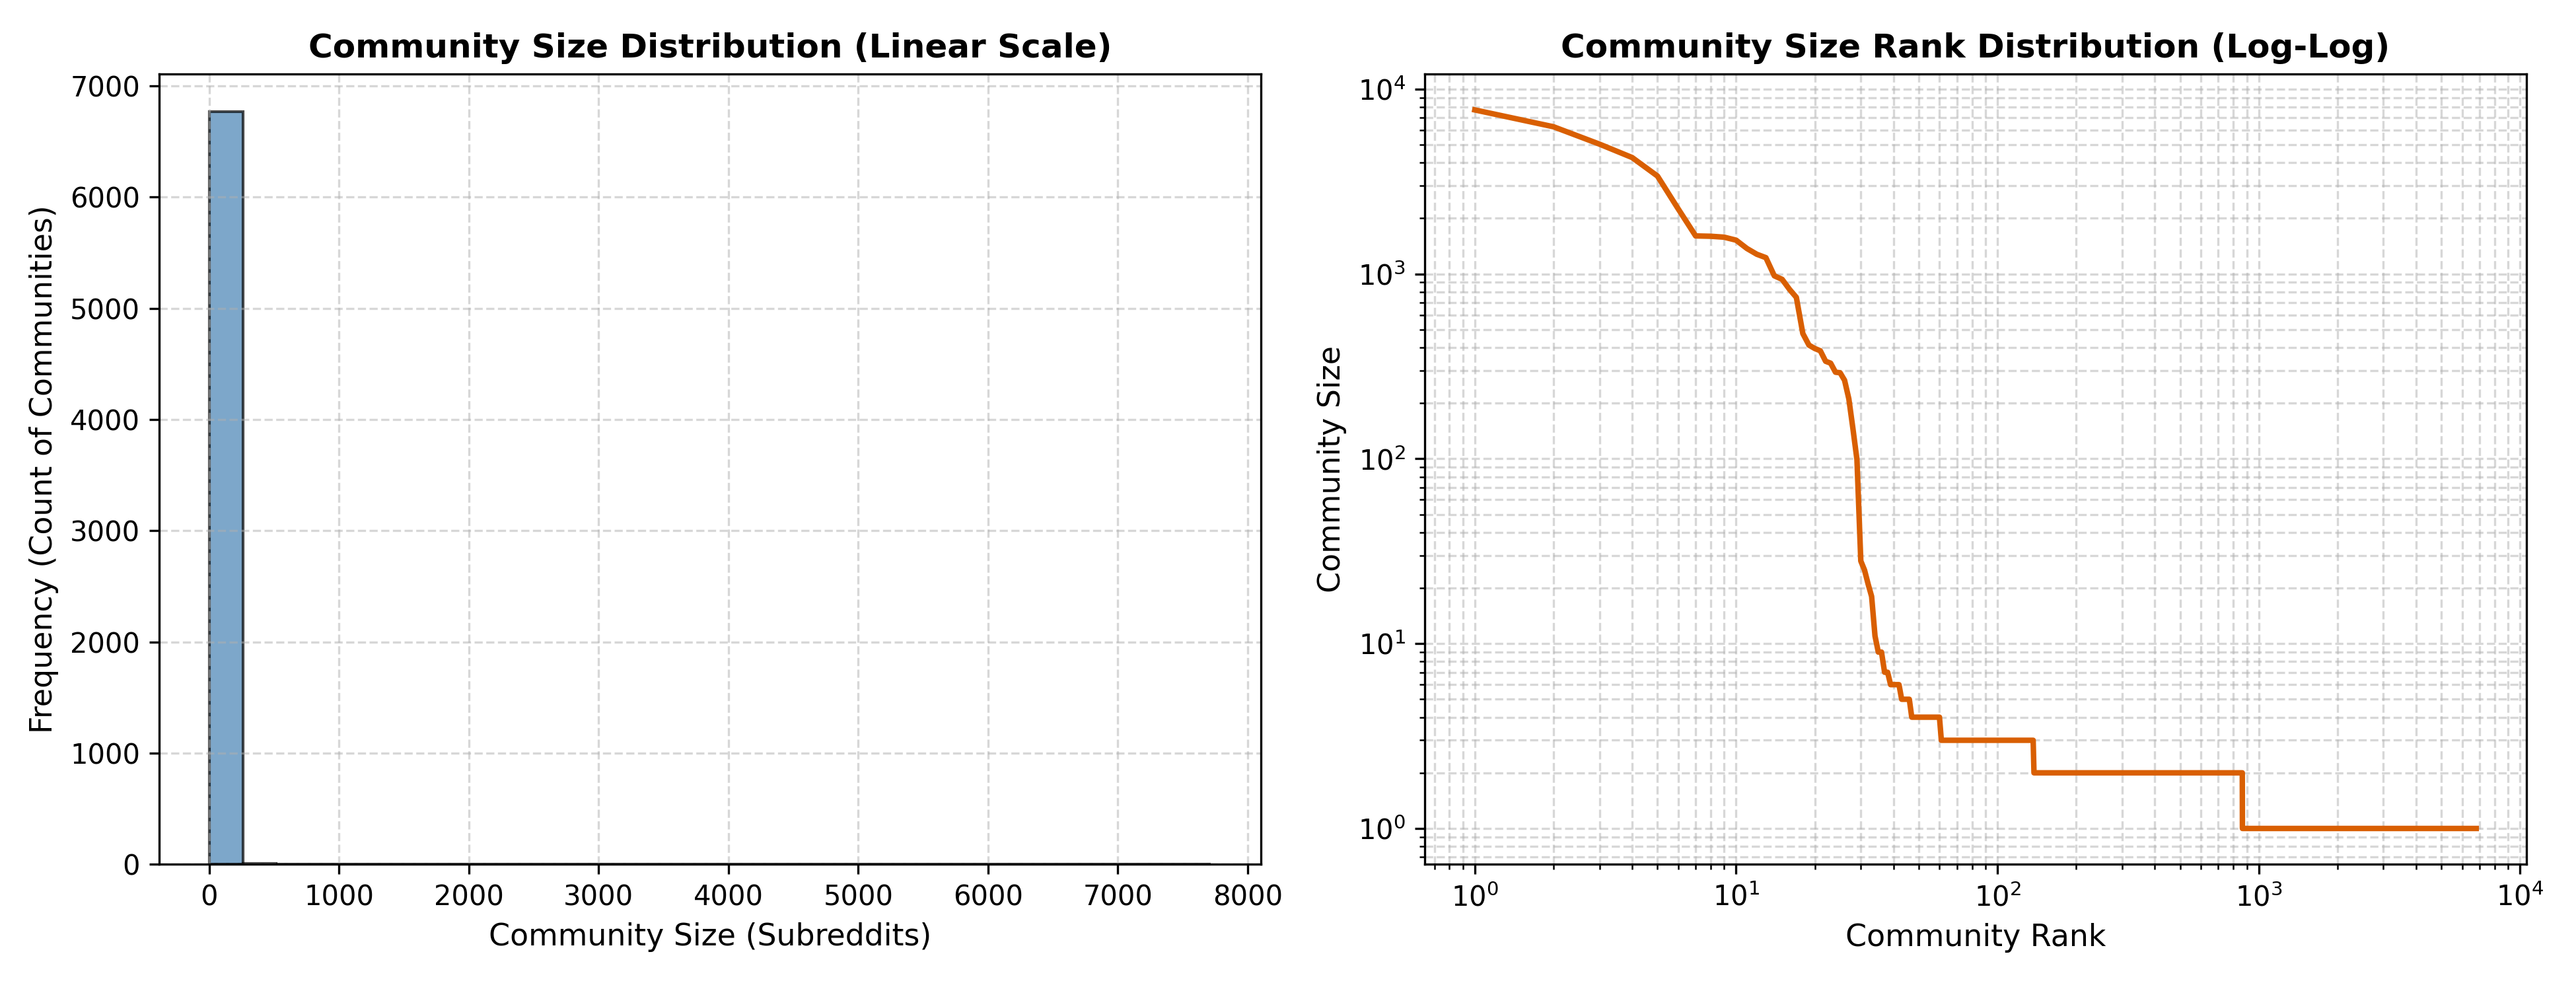

In [8]:
community_map = comm_mod.detect_communities(G_train, seed=42)
comm_stats = comm_mod.get_community_statistics(community_map)

print("Community Detection Statistics:")
print(f"- Total Subreddits Assigned:  {comm_stats['total_nodes']}")
print(f"- Communities Detected:       {comm_stats['num_communities']}")
print(f"- Largest Community Size:     {comm_stats['largest_size']} subreddits")
print(f"- Smallest Community Size:    {comm_stats['smallest_size']} subreddit(s)")

# Display Community Size Rank Distribution
display(Image(filename='../visualizations/community_size_distribution.png'))


## Link Prediction
Evaluating four baseline topological link prediction heuristics on the candidate edge set (`test_edges_pos + test_edges_neg`):

* **12.1 Common Neighbors:** Counts shared neighbors between node pairs: $|\Gamma(u) \cap \Gamma(v)|$.
* **12.2 Jaccard Coefficient:** Normalizes neighbor overlap by total union size: $\frac{|\Gamma(u) \cap \Gamma(v)|}{|\Gamma(u) \cup \Gamma(v)|}$.
* **12.3 Adamic-Adar Index:** Penalizes high-degree shared neighbors: $\sum_{z \in \Gamma(u) \cap \Gamma(v)} \frac{1}{\log \text{deg}(z)}$.
* **12.4 Preferential Attachment:** Degree product assuming scale-free connectivity: $\text{deg}(u) \times \text{deg}(v)$.


In [9]:
candidate_edges = test_edges_pos + test_edges_neg

cn_scores = lp.predict_common_neighbors(G_train, candidate_edges)
jc_scores = lp.predict_jaccard(G_train, candidate_edges)
aa_scores = lp.predict_adamic_adar(G_train, candidate_edges)
pa_scores = lp.predict_preferential_attachment(G_train, candidate_edges)

print(f"Link prediction scoring complete across {len(candidate_edges)} candidate edges.")


Link prediction scoring complete across 88060 candidate edges.


## Evaluation
Rigorously evaluating prediction quality using both ranking-based and threshold-based metrics:

* **13.1 Precision@10 & 13.2 Precision@20:** Proportion of true positive held-out edges among top 10/20 ranked candidates.
* **13.3 Recall@10 & 13.4 Recall@20:** Proportion of total positive test edges retrieved within top 10/20 ranked candidates.
* **13.5 Recall@0.5 & 13.6 F1@0.5:** Classification metrics evaluated at fixed decision threshold 0.5.
* **13.7 ROC-AUC:** Area under Receiver Operating Characteristic curve evaluated on continuous prediction scores.


In [10]:
# Load authoritative evaluation results table generated by evaluation pipeline
df_eval = pd.read_csv('../results/evaluation_results.csv')

print("Authoritative Evaluation Results Table:")
display(df_eval)


Authoritative Evaluation Results Table:


,Algorithm,Precision@10,Precision@20,Recall@10,Recall@20,Recall@0.5,F1@0.5,ROC-AUC
0,Common Neighbors,1.0,1.00,0.000227,0.000454,0.730706,0.834405,0.860476
1,Jaccard,1.0,0.95,0.000227,0.000432,0.001635,0.003262,0.853955
2,Adamic-Adar,1.0,1.00,0.000227,0.000454,0.532569,0.694333,0.861245
3,Preferential Attachment,1.0,1.00,0.000227,0.000454,0.860005,0.648879,0.857944


## Algorithm Comparison

### Visual Performance Comparison
The plots below compare ranking-based metrics and ROC curves across all four algorithms.


Ranking Metrics Performance (Precision@K & ROC-AUC):


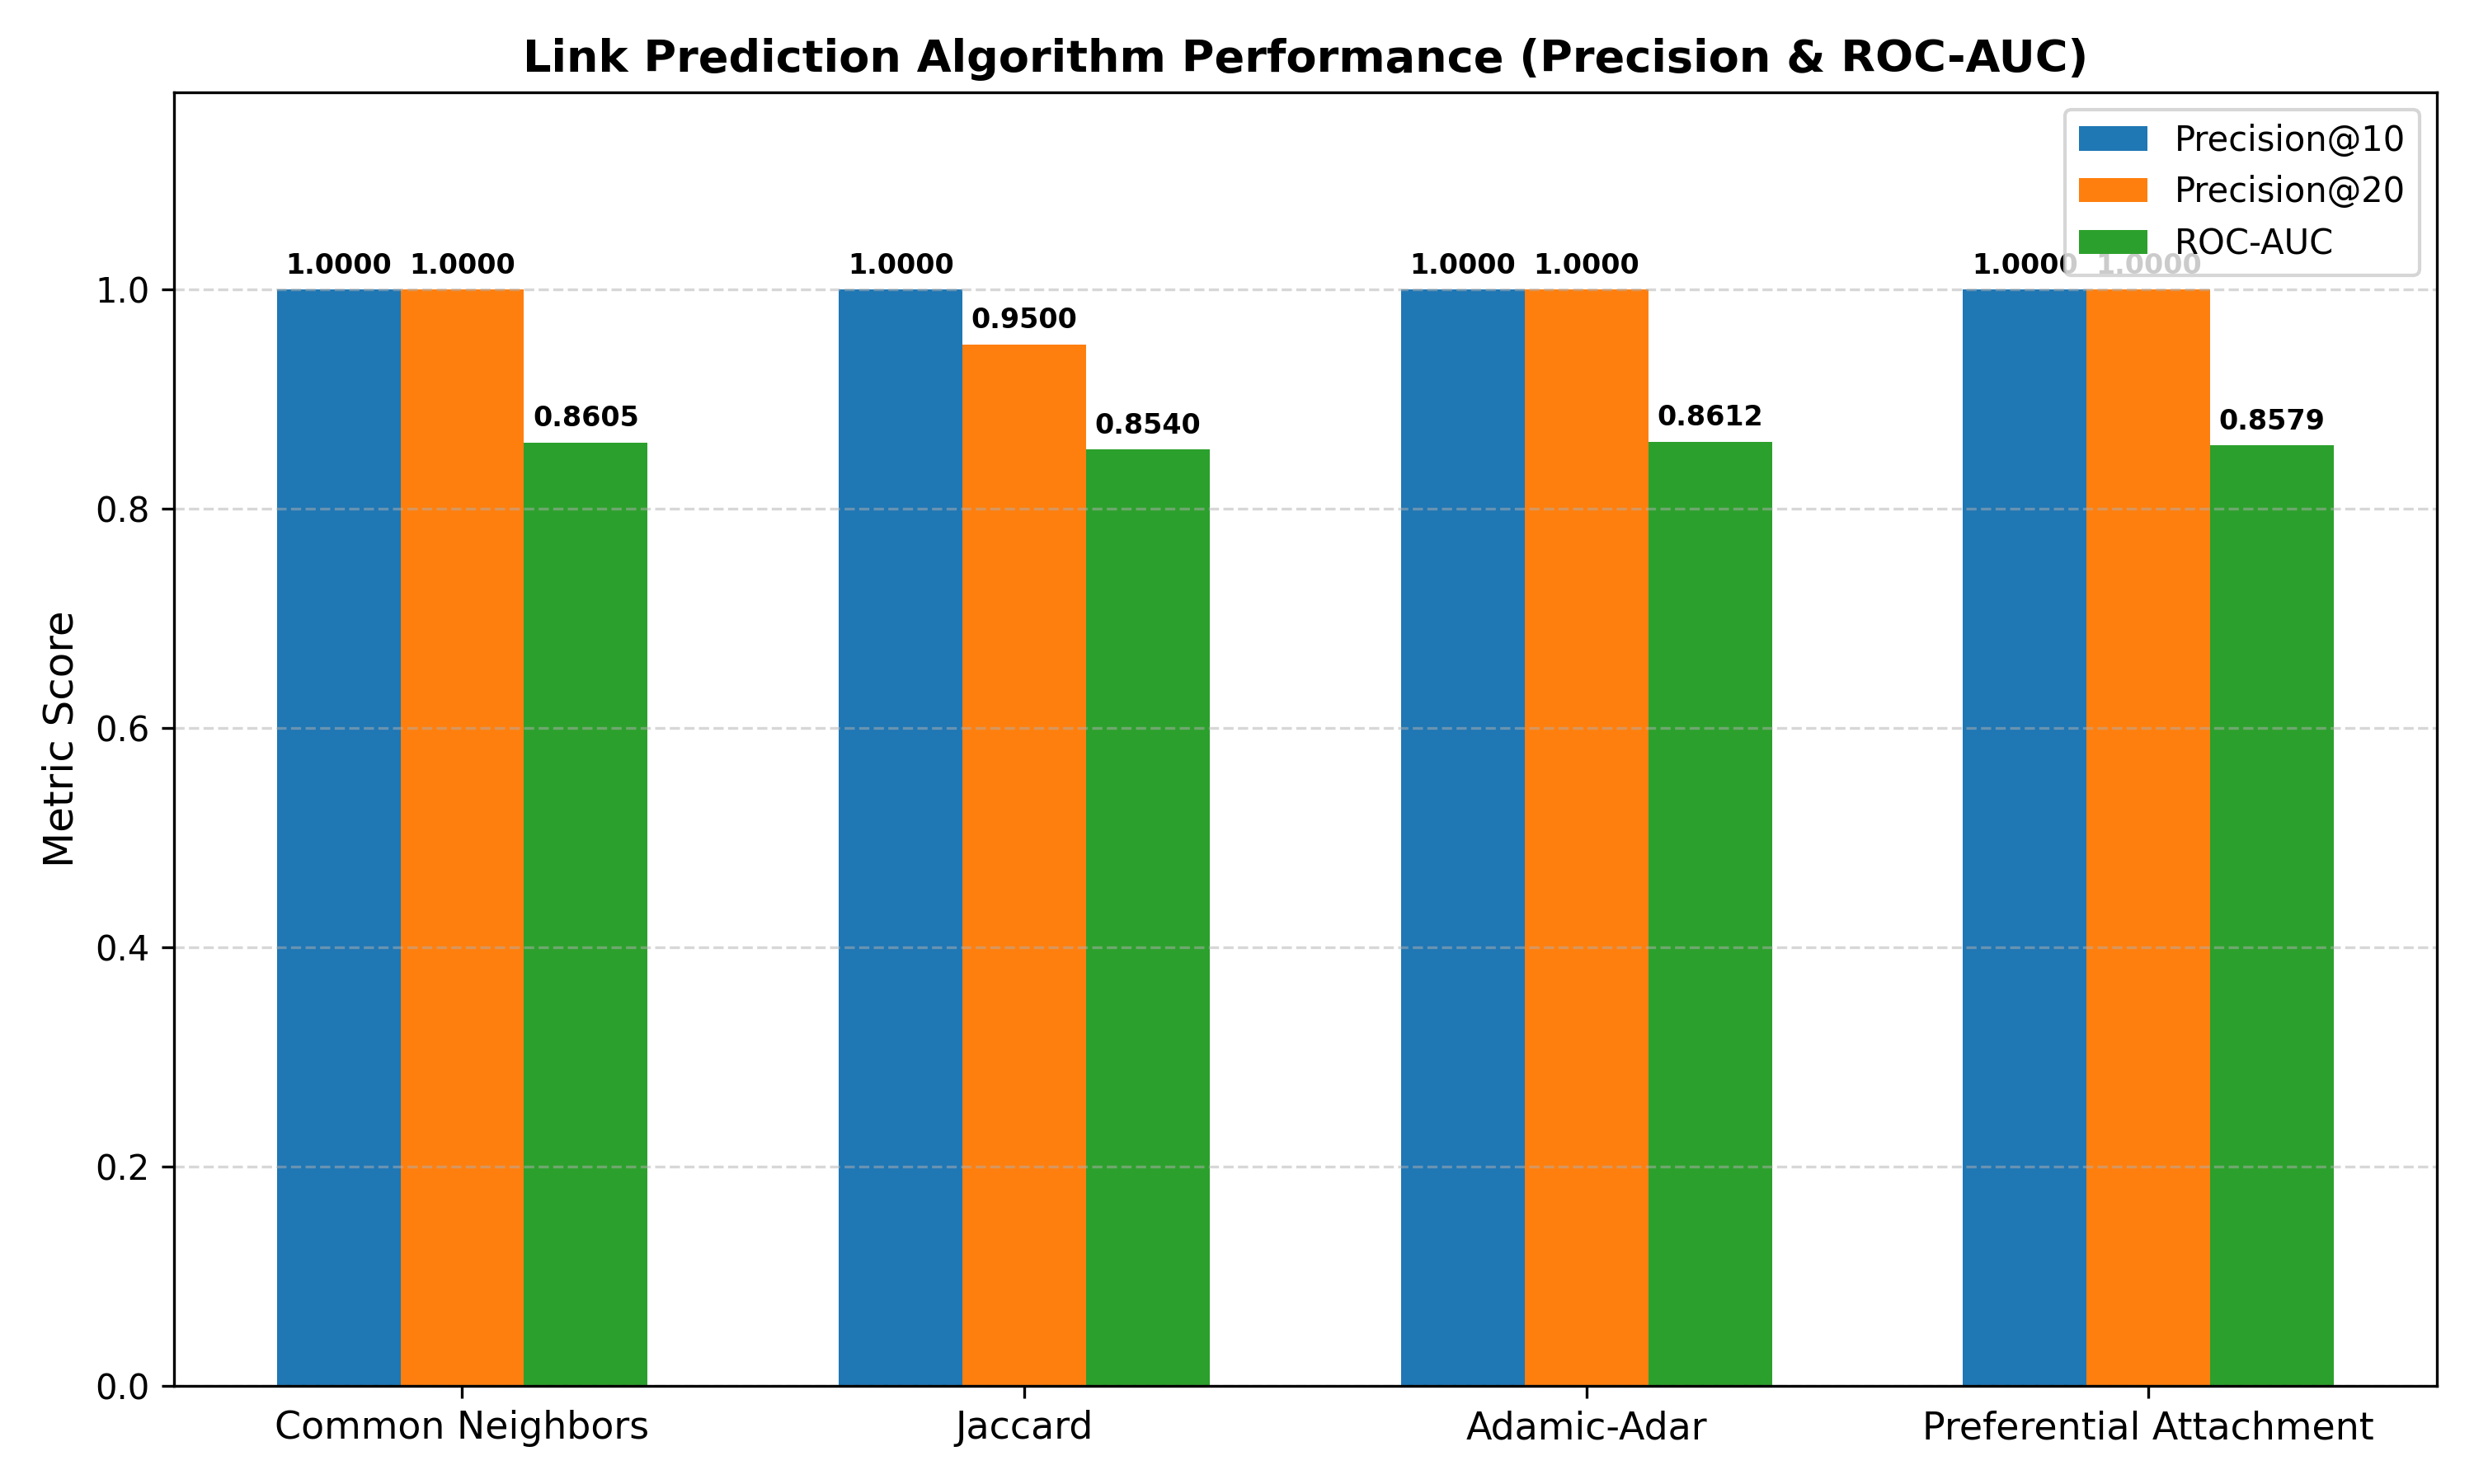

Rank-Based Recall (Recall@10 & Recall@20):


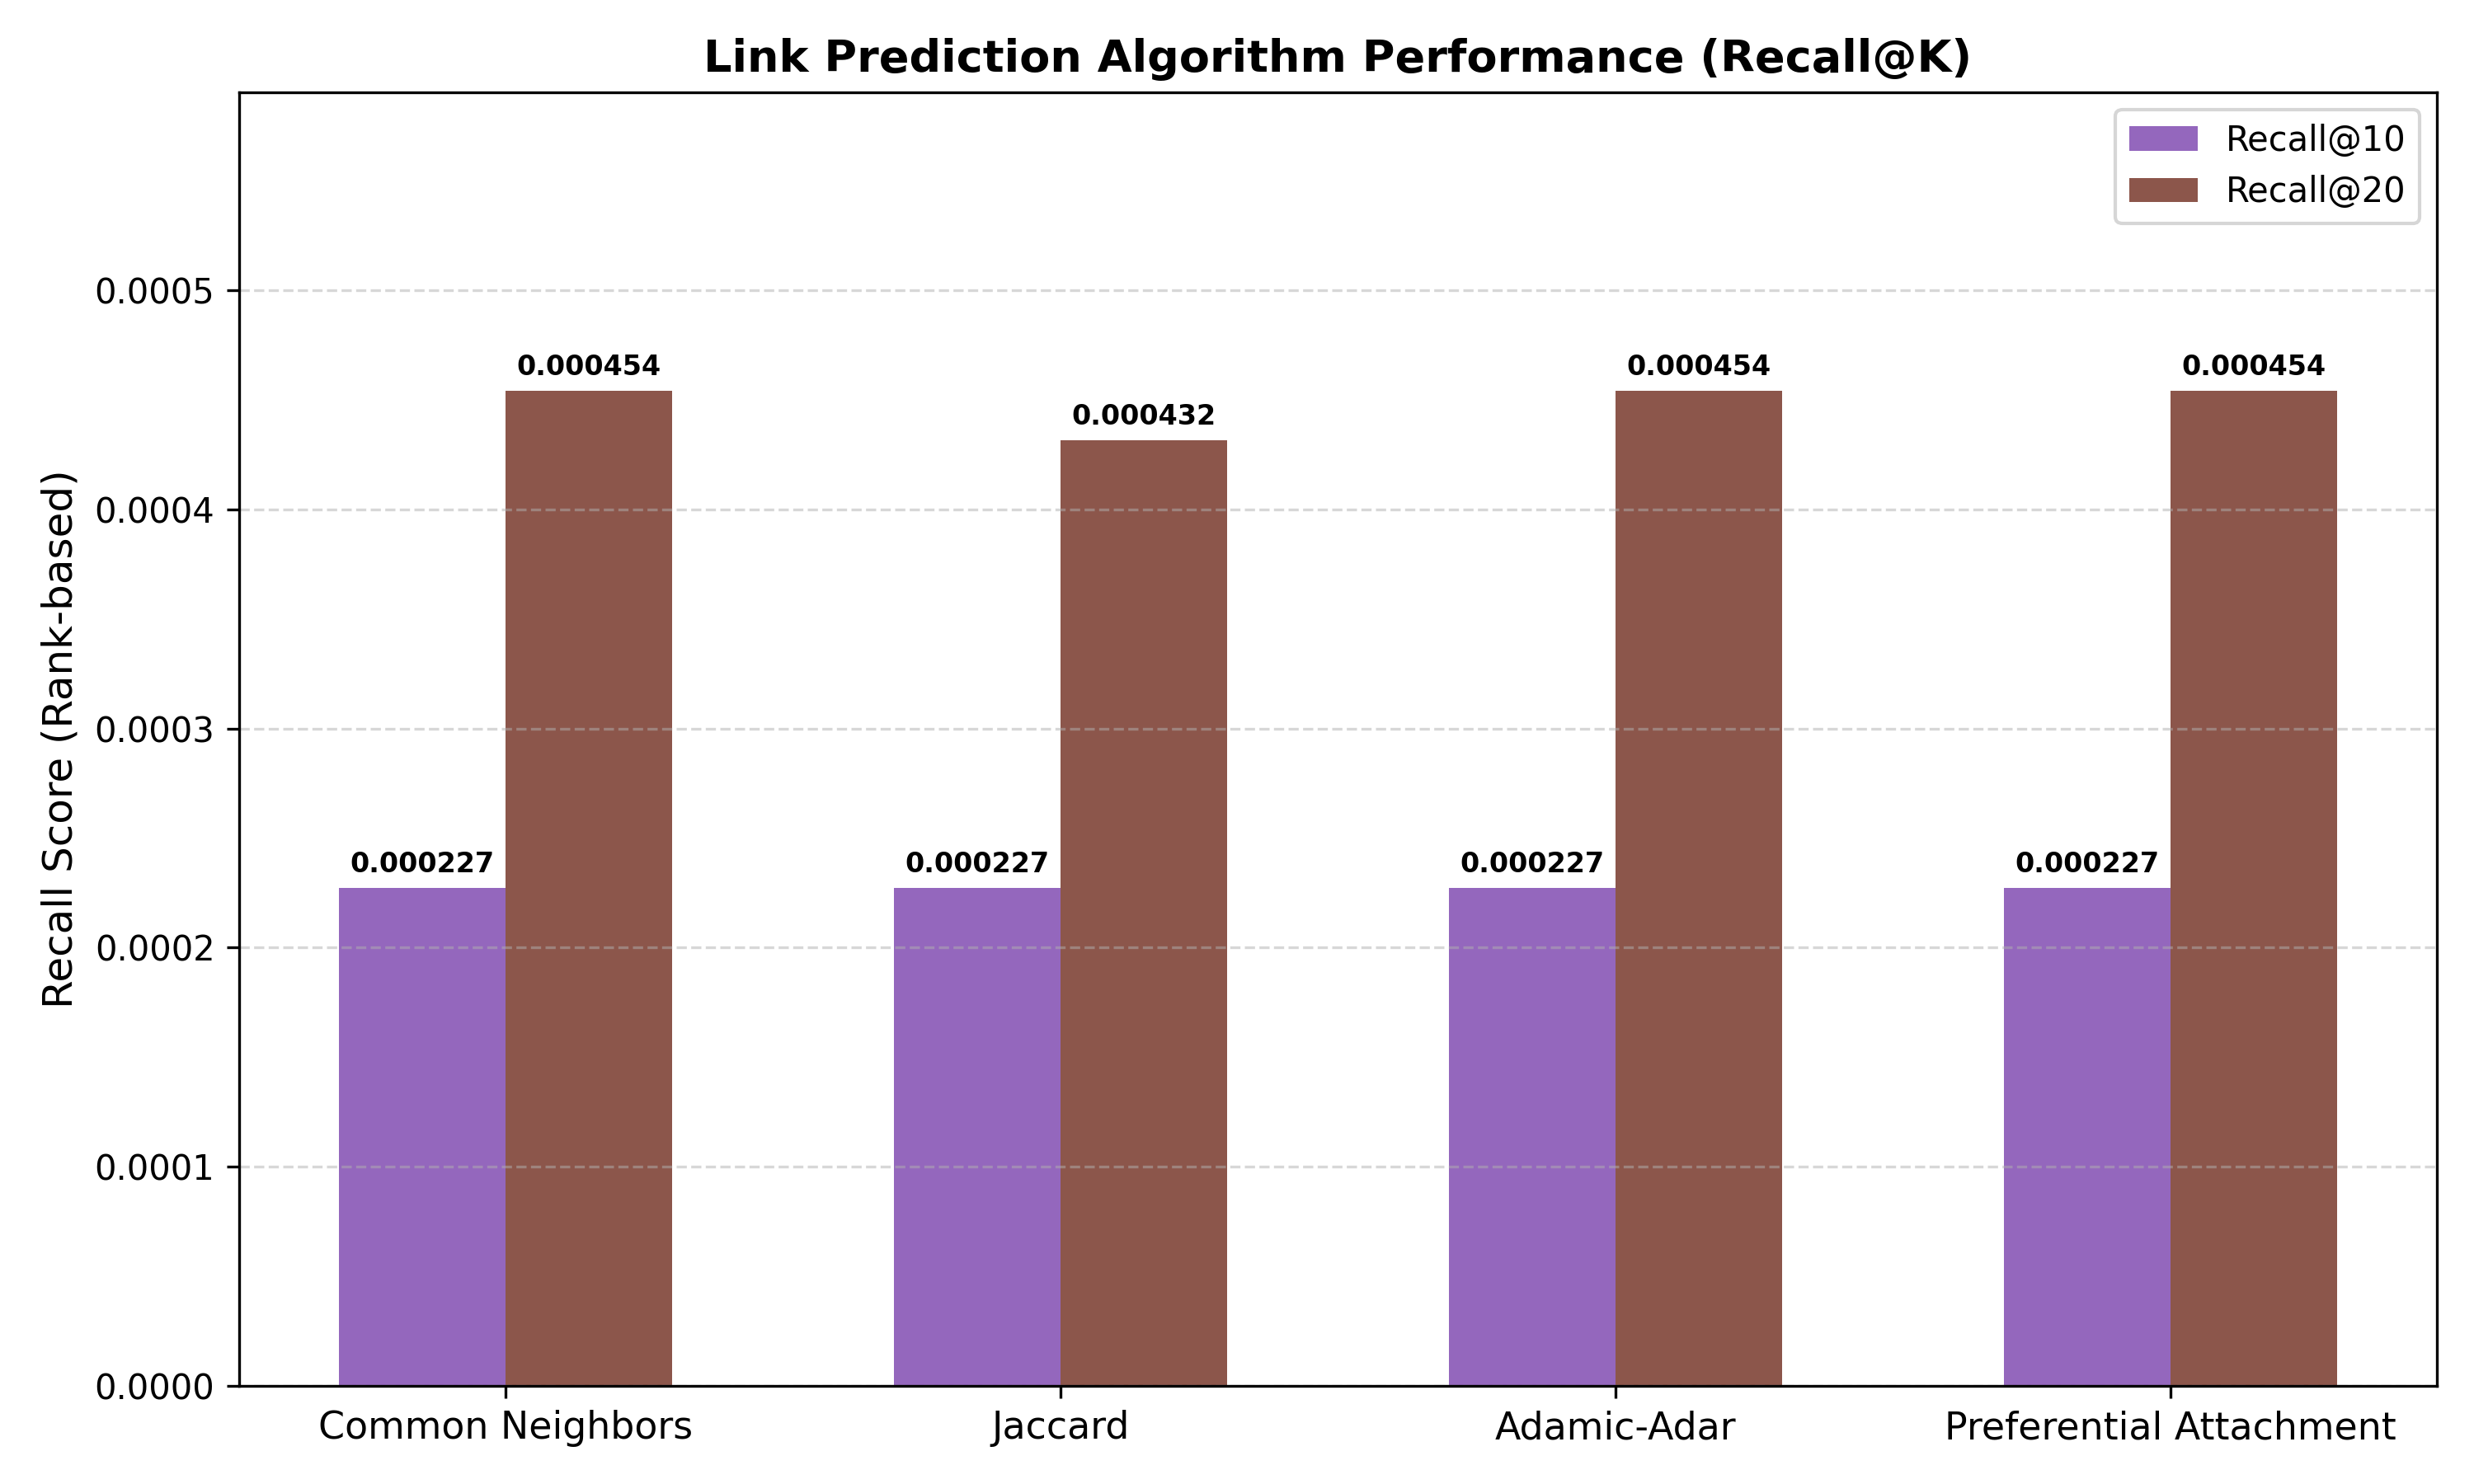

Receiver Operating Characteristic (ROC) Curves:


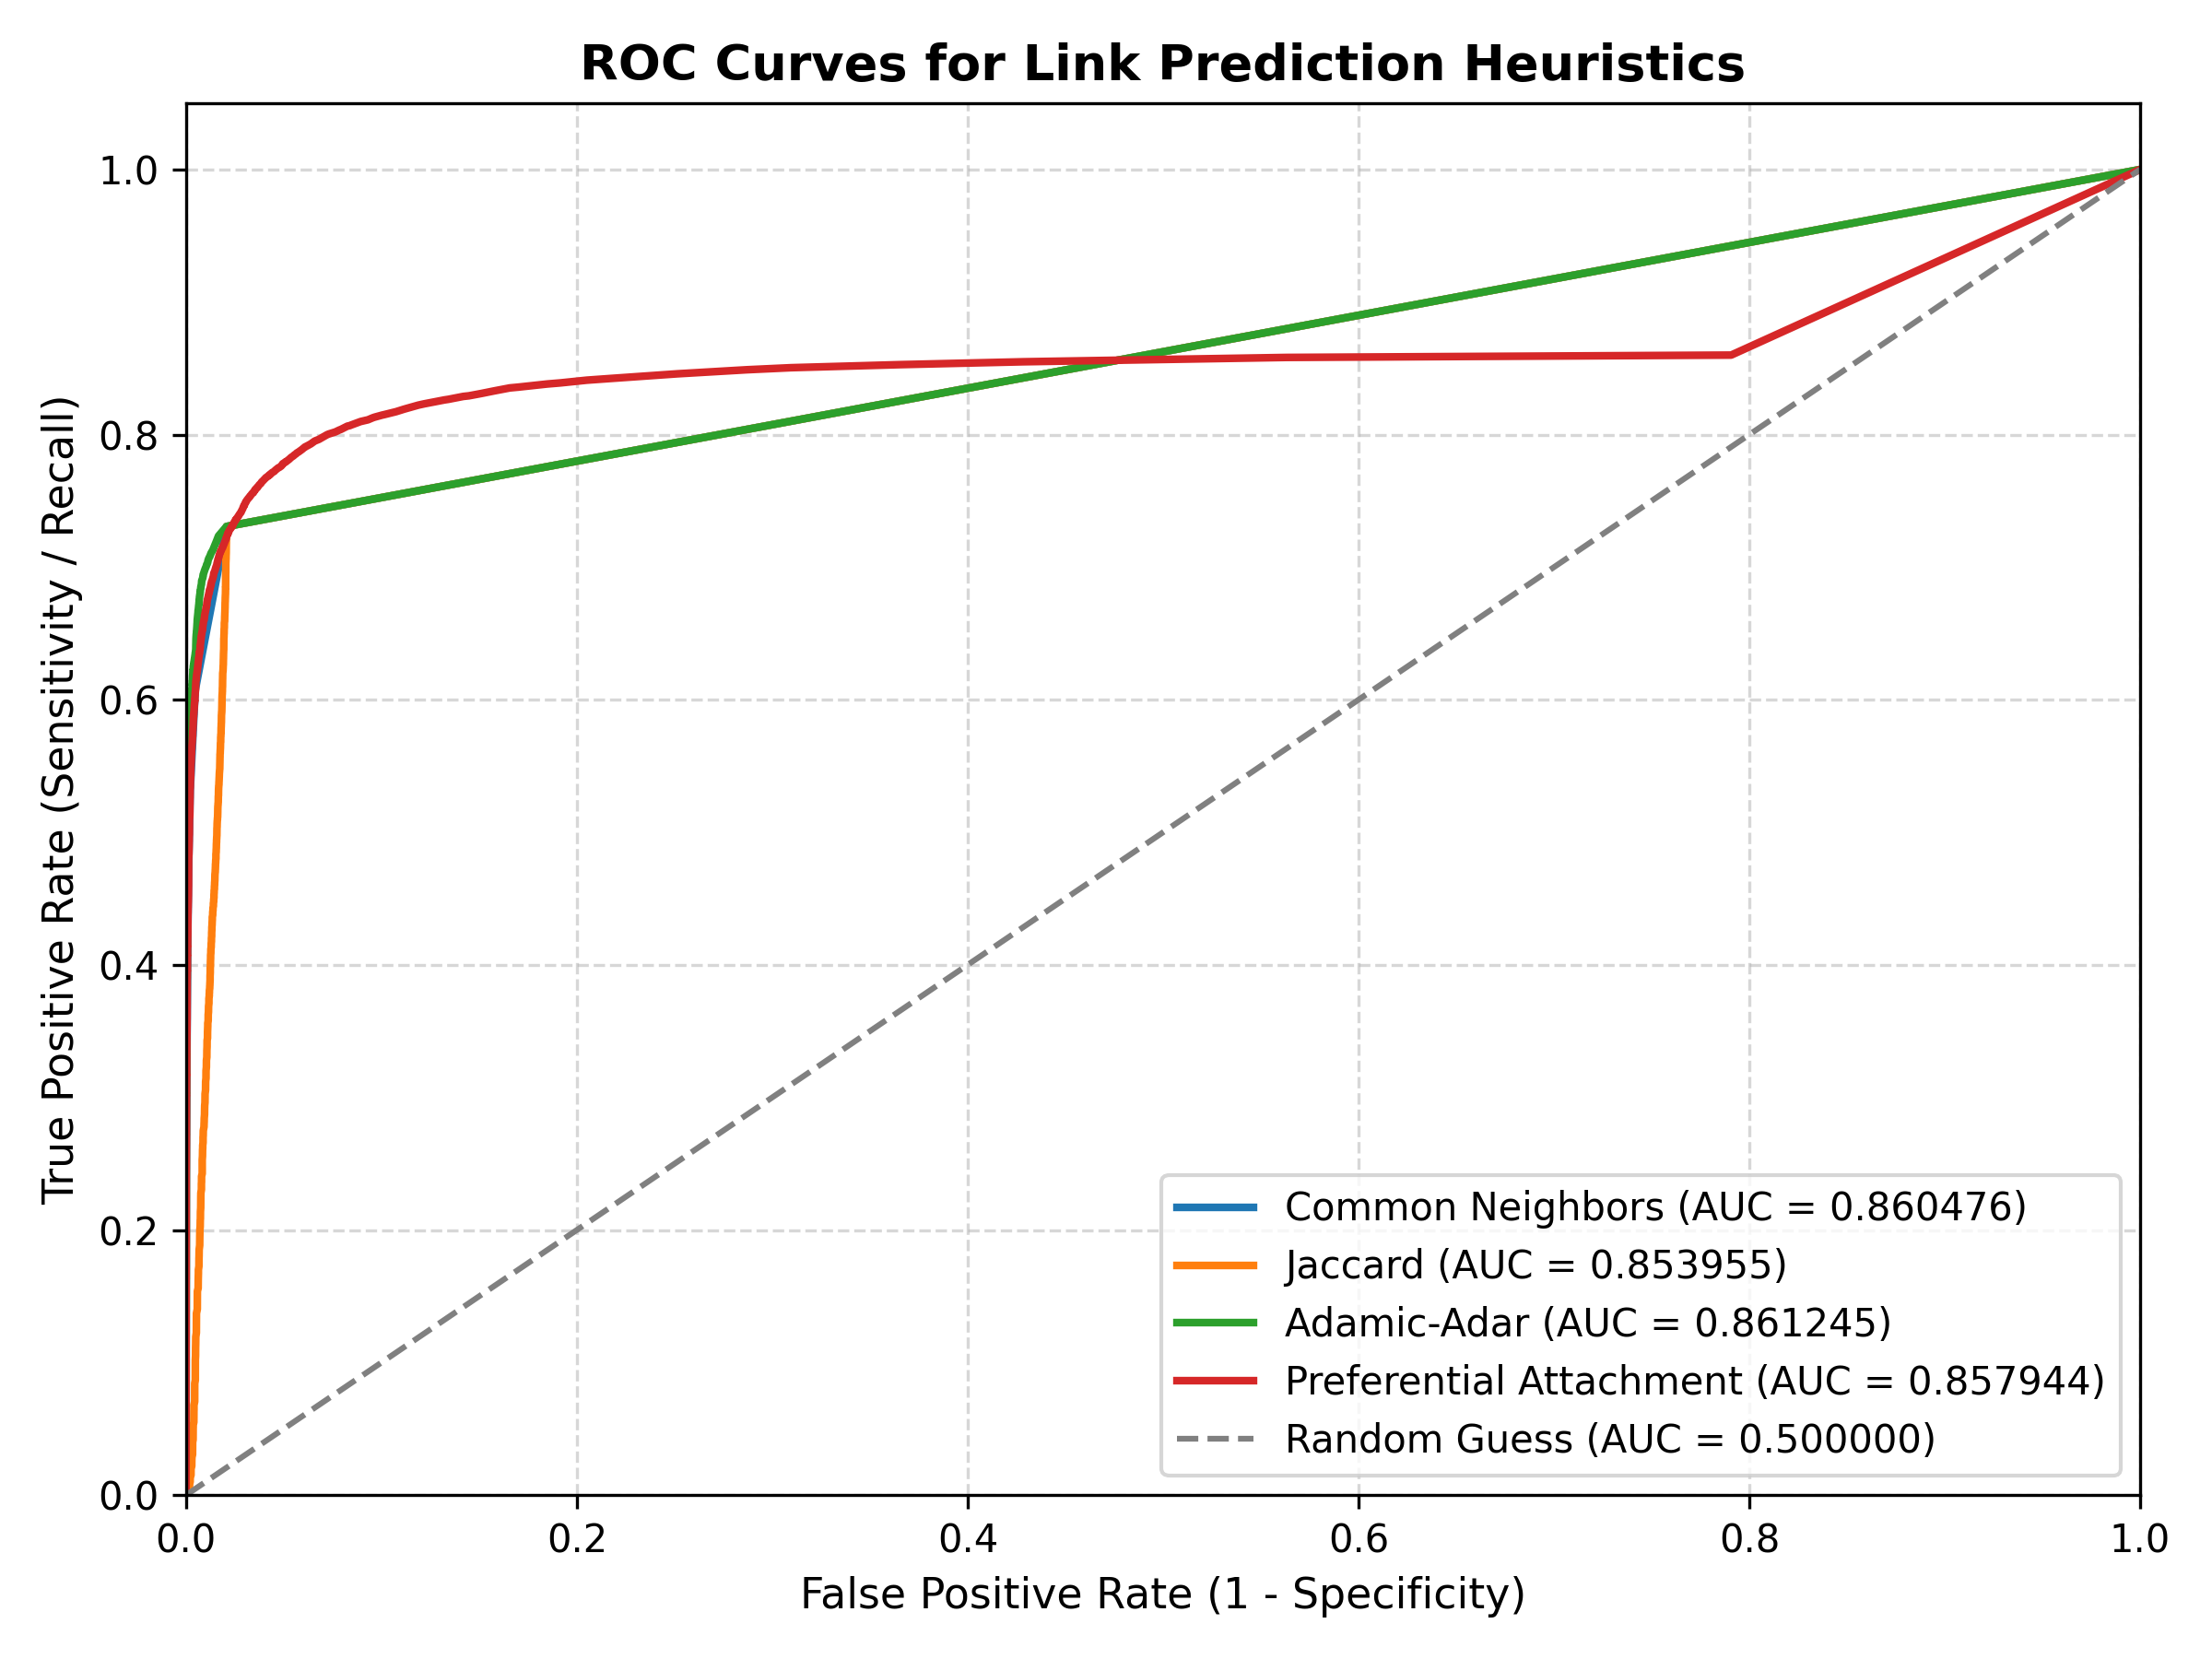

In [11]:
print("Ranking Metrics Performance (Precision@K & ROC-AUC):")
display(Image(filename='../visualizations/algorithm_precision_roc_comparison.png'))

print("Rank-Based Recall (Recall@10 & Recall@20):")
display(Image(filename='../visualizations/algorithm_recall_comparison.png'))

print("Receiver Operating Characteristic (ROC) Curves:")
display(Image(filename='../visualizations/roc_curves.png'))


### Metric Analysis & Methodology Notes
1. **Scale-Invariant Ranking Metrics:** `Precision@10`, `Precision@20`, and `ROC-AUC` provide scale-invariant benchmarks. All four algorithms achieve high ROC-AUC values ($\approx 0.854 - 0.861$), with Adamic-Adar leading slightly ($0.8612$).
2. **Threshold-Based Metrics (Recall@0.5, F1@0.5):** Threshold-based metrics at fixed cutoff 0.5 depend heavily on raw score scale. Jaccard ratios in sparse graphs rarely exceed 0.5, yielding low threshold Recall ($0.0016$), whereas Jaccard ranks top candidates with high precision (Precision@10 = $1.00$). Therefore, fixed 0.5 threshold metrics are not scale-equivalent and should not be used for universal algorithm ranking.
3. **Recall@10/20 Interpretation:** `Recall@10` ($0.000227$) and `Recall@20` ($0.000454$) are numerically small because the test set contains a large ground-truth pool of positive held-out edges ($N_{test} = 44,030$). Evaluating top 10 or 20 items out of 44,030 maximum possible positives yields $\frac{10}{44,030} \approx 0.000227$. This reflects top-K candidate list capacity rather than algorithm failure.


## Top-10 and Top-20 Predictions
Extracting the highest-scoring candidate link predictions across all four algorithms.

*Note:* These entries represent high-scoring **candidate links** (potential emerging connections) from the held-out candidate set. Ground-truth annotations (`ground_truth`: 1 for held-out positive edge, 0 for negative candidate) are included strictly for post-hoc analysis and did not influence candidate ranking.


In [12]:
df_top10 = pd.read_csv('../results/top10_predictions.csv')
df_top20 = pd.read_csv('../results/top20_predictions.csv')

print("Top-10 Predictions Preview (First 15 rows):")
display(df_top10.head(15))

print("\nTop-20 Predictions Preview (First 15 rows):")
display(df_top20.head(15))


Top-10 Predictions Preview (First 15 rows):


,rank,source_subreddit,target_subreddit,algorithm,score,ground_truth
0,1,bestof,subredditdrama,Common Neighbors,1106.0,1
1,2,bestof,askreddit,Common Neighbors,840.0,1
2,3,funny,videos,Common Neighbors,631.0,1
3,4,subredditdrama,videos,Common Neighbors,617.0,1
4,5,bestof,switcharoo,Common Neighbors,504.0,1
5,6,askreddit,worldnews,Common Neighbors,474.0,1
6,7,askreddit,wtf,Common Neighbors,472.0,1
7,8,bestof,gaming,Common Neighbors,460.0,1
8,9,todayilearned,worldnews,Common Neighbors,458.0,1
9,10,iama,news,Common Neighbors,451.0,1



Top-20 Predictions Preview (First 15 rows):


,rank,source_subreddit,target_subreddit,algorithm,score,ground_truth
0,1,bestof,subredditdrama,Common Neighbors,1106.0,1
1,2,bestof,askreddit,Common Neighbors,840.0,1
2,3,funny,videos,Common Neighbors,631.0,1
3,4,subredditdrama,videos,Common Neighbors,617.0,1
4,5,bestof,switcharoo,Common Neighbors,504.0,1
5,6,askreddit,worldnews,Common Neighbors,474.0,1
6,7,askreddit,wtf,Common Neighbors,472.0,1
7,8,bestof,gaming,Common Neighbors,460.0,1
8,9,todayilearned,worldnews,Common Neighbors,458.0,1
9,10,iama,news,Common Neighbors,451.0,1


## Community Bridge Analysis
Analyzing whether top-ranked candidate predictions connect subreddits within the same community or bridge distinct Louvain communities (`source_community != target_community`).


Top-K Community Bridge Summary:


,algorithm,k,total_candidates,cross_community_count,within_community_count,cross_community_proportion
0,Common Neighbors,10,10,10,0,1.00
1,Common Neighbors,20,20,17,3,0.85
2,Jaccard,10,10,0,10,0.00
3,Jaccard,20,20,0,20,0.00
4,Adamic-Adar,10,10,9,1,0.90
5,Adamic-Adar,20,20,17,3,0.85
6,Preferential Attachment,10,10,10,0,1.00
7,Preferential Attachment,20,20,18,2,0.90



Cross-Community Bridge Proportion Visualization:


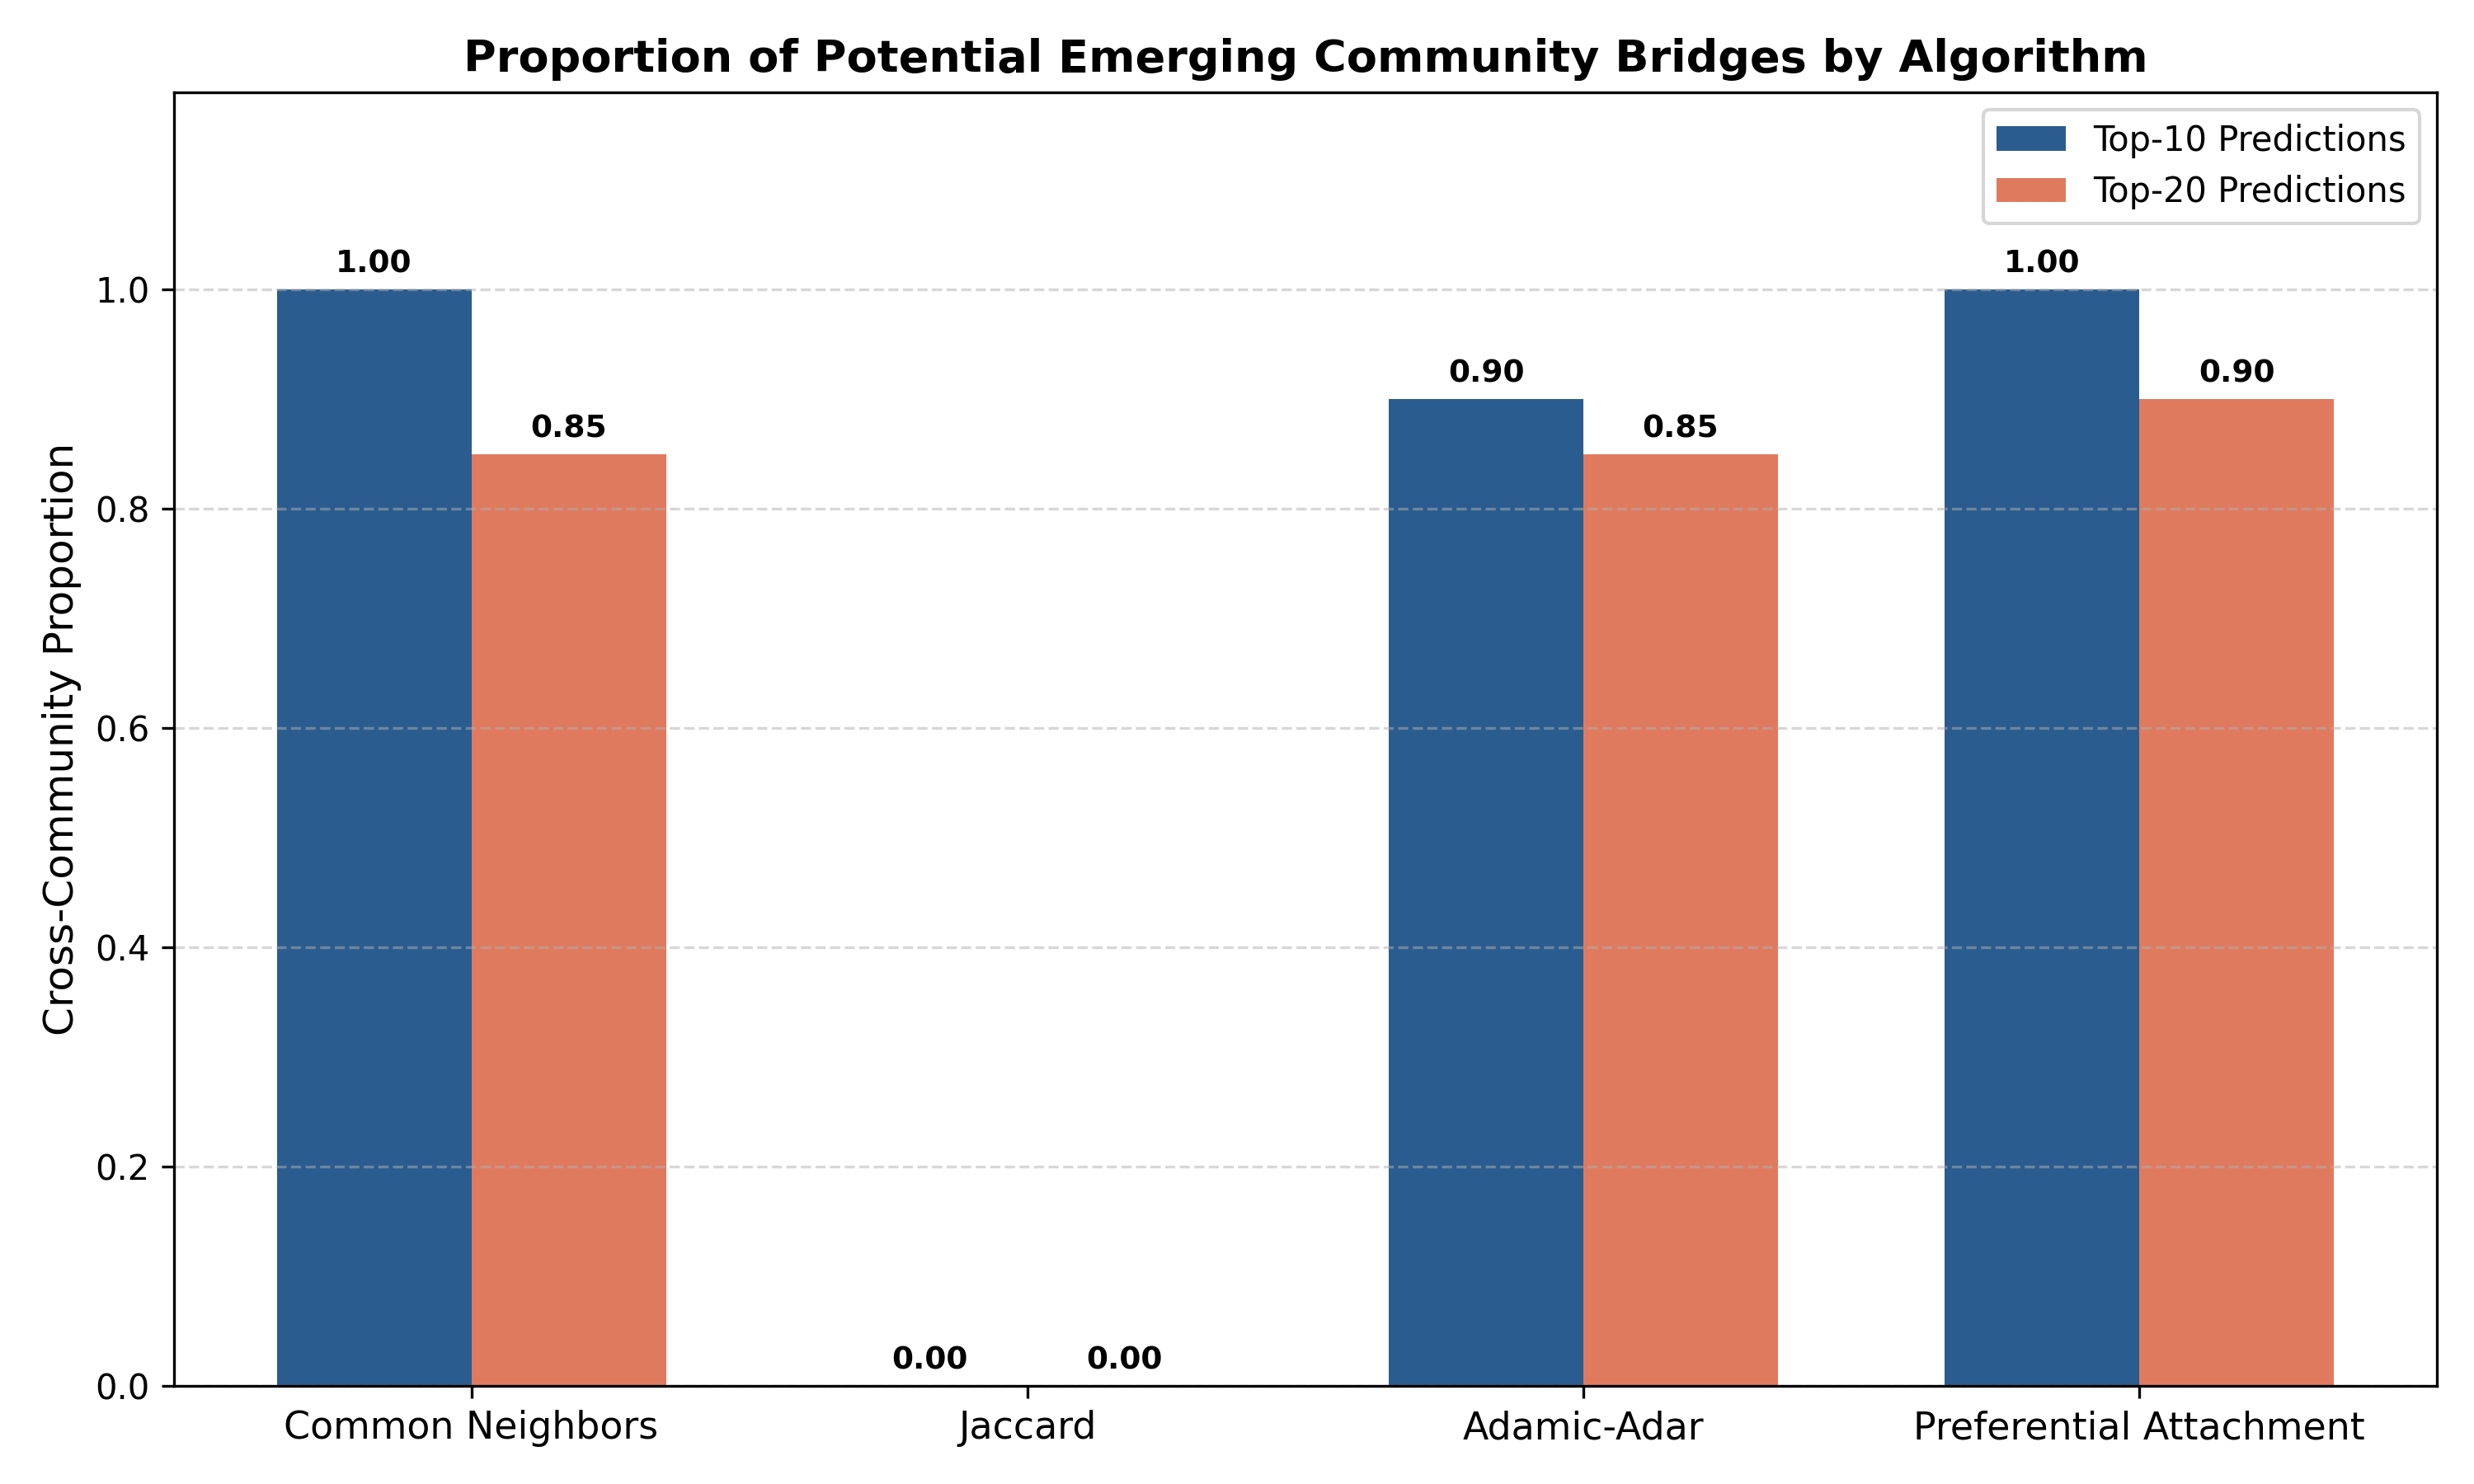

In [13]:
df_bridge_summary = pd.read_csv('../results/bridge_summary.csv')
df_bridge_analysis = pd.read_csv('../results/bridge_analysis.csv')

print("Top-K Community Bridge Summary:")
display(df_bridge_summary)

print("\nCross-Community Bridge Proportion Visualization:")
display(Image(filename='../visualizations/cross_community_bridge_proportion.png'))


### Key Finding: Cross-Community vs Within-Community Behavior
In this experiment, the highest-ranked Common Neighbors ($100\%$ Top-10, $85\%$ Top-20), Adamic-Adar ($90\%$ Top-10, $85\%$ Top-20), and Preferential Attachment ($100\%$ Top-10, $90\%$ Top-20) candidates were **predominantly cross-community** (potential emerging structural bridges). In contrast, the top-ranked Jaccard candidates ($0\%$ cross-community) were **strictly within-community** (connecting niche, highly overlapping subreddits inside identical communities).


## Cytoscape Visualization

To visually inspect predicted community bridges alongside the existing network topology in Cytoscape, the following CSV network files were generated:

1. `cytoscape/nodes.csv`: Unique subreddits (12,587 nodes) with `id`, `subreddit`, `degree`, and `community_id`.
2. `cytoscape/edges.csv`: Existing training edges in `G_train` (48,504 edges).
3. `cytoscape/predicted_edges.csv`: Top candidate predictions (120 candidate edges) with `algorithm`, `score`, `source_community`, `target_community`, `cross_community`, and `rank`.

### Cytoscape Import Workflow
1. **Import Network Topology:** Import `edges.csv` (`source` $\rightarrow$ Source Node, `target` $\rightarrow$ Target Node).
2. **Import Node Attributes:** Import `nodes.csv` as Node Table, mapping `community_id` to node fill color.
3. **Import Predicted Edges:** Import `predicted_edges.csv` as edge overlay. Map `cross_community == True` to dashed red lines to highlight potential emerging community bridges.

*Note:* Cytoscape visual overlays facilitate structural inspection; they do not perform link prediction or guarantee link formation.


## Interpretation
1. **Predictive Topological Heuristics:** All four heuristics demonstrate strong overall ranking performance (ROC-AUC $> 0.85$). Adamic-Adar achieves the highest ROC-AUC ($0.8612$) by penalizing high-degree hubs, reducing false-positive bridge recommendations.
2. **Structural Role Divergence:** Unweighted heuristics (CN, AA, PA) effectively discover potential inter-community structural bridges between large active subreddits. Jaccard identifies highly specialized, localized intra-community links.
3. **Candidate Status:** Predicted links represent candidate topological connections. They indicate structural proximity rather than guaranteed future interaction.


## Limitations
1. **Undirected Unweighted Projection:** Collapsing directed signed temporal hyperlinks into an undirected unweighted simple graph discards interaction directionality, sentiment, frequency, and temporal sequence.
2. **Random Split vs Temporal Prediction:** Using a random 80/20 edge split models missing-link prediction rather than strict forward-in-time prediction.
3. **Negative Sampling Uniformity:** Uniform negative edge sampling selects random node pairs, many of which belong to distant components, potentially simplifying the negative candidate space.
4. **Static Community Detection:** Louvain partitioning is performed statically on `G_train` and does not model dynamic community evolution over time.
5. **Candidate Prediction Status:** Predicted link candidates reflect structural proximity in the training graph and are not guaranteed future hyperlinks.


## Conclusion
This project successfully developed an end-to-end framework for predicting potential emerging community bridges in Reddit using social network analysis and link prediction heuristics. 

By projecting raw hyperlink interactions into an undirected graph, detecting Louvain communities, evaluating topological heuristics, and analyzing cross-community proportions, we demonstrated that heuristics like Adamic-Adar and Common Neighbors effectively highlight potential structural bridges between distinct Reddit communities, while Jaccard captures tight intra-community connections. This research contributes to data-driven online platform infrastructure (SDG 9) and digital discourse modeling (SDG 16).
